In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.15.0
GPU available: True


In [2]:
%matplotlib inline

In [3]:
data = pd.read_csv('../data/Paysim1.csv')

In [4]:
data.columns
# Display basic information
print(data.head())
print(data.info())
print(data.describe())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 co

In [5]:
# Drop non-informative columns
data = data.drop(columns=["nameOrig", "nameDest"])

# Check for missing values
print(data.isnull().sum())


step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode the 'type' column
le = LabelEncoder()
data["type"] = le.fit_transform(data["type"])
print("Type mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Type mapping: {'CASH_IN': 0, 'CASH_OUT': 1, 'DEBIT': 2, 'PAYMENT': 3, 'TRANSFER': 4}


In [7]:
print(data.columns)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')


In [8]:
# Use the correct column names:
data["balance_diff_orig"] = data["oldbalanceOrg"] - data["newbalanceOrig"]
data["balance_diff_dest"] = data["oldbalanceDest"] - data["newbalanceDest"]

# Create binary flags for zero balances using the correct column names
data["zero_balance_orig"] = (data["oldbalanceOrg"] == 0).astype(int)
data["zero_balance_dest"] = (data["oldbalanceDest"] == 0).astype(int)


In [9]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    "amount",            # lowercase 'amount'
    "oldbalanceOrg",     # correct spelling as in your DataFrame
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    # Only include these engineered columns if they have been created
    "balance_diff_orig",  
    "balance_diff_dest"
]

# If you haven't created the engineered features yet, remove them:
scale_cols = [
    "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"
]

scaler = StandardScaler()
data[scale_cols] = scaler.fit_transform(data[scale_cols])


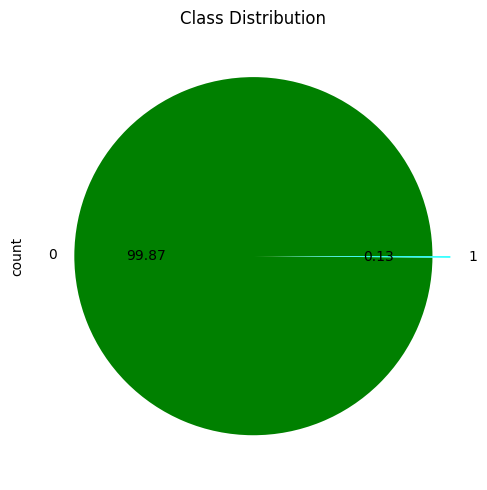

In [10]:
data.isFraud.value_counts().plot.pie(autopct='%.2f',figsize=(5, 5), colors=["green","cyan"], explode=[0,.1])
plt.title('Class Distribution')
plt.tight_layout()

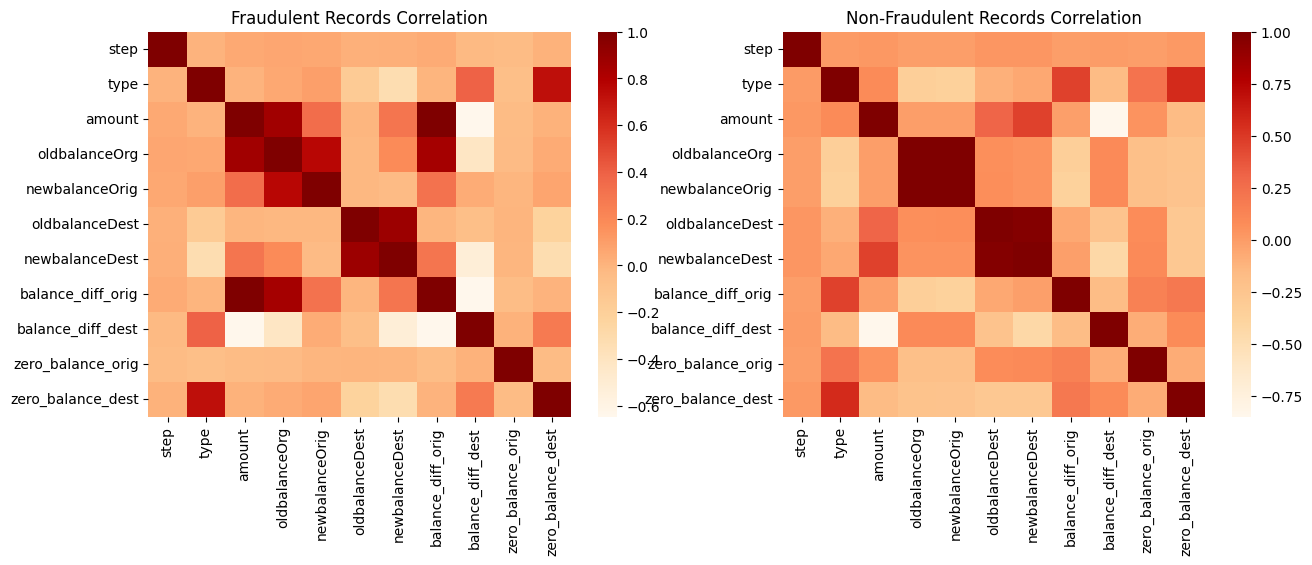

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Select only numeric features
numeric_data = data.select_dtypes(include=['number'])

ax[0].set_title("Fraudulent Records Correlation")
sns.heatmap(numeric_data.query('isFraud == 1').drop(['isFraud', 'isFlaggedFraud'], axis=1).corr(), cmap="OrRd", ax=ax[0])

ax[1].set_title("Non-Fraudulent Records Correlation")
sns.heatmap(numeric_data.query('isFraud == 0').drop(['isFraud', 'isFlaggedFraud'], axis=1).corr(), cmap="OrRd", ax=ax[1])

plt.show()

# Train test and split

In [12]:
import pandas as pd
import numpy as np

# Identify numeric columns, excluding boolean ones
numeric_features = data.select_dtypes(include=['int64', 'float64']).columns

# Apply Min-Max scaling only to numeric columns
data[numeric_features] = data[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else x
)

# Fill empty values with 0
data.fillna(0, inplace=True)

print("Min-Max scaling applied successfully!")

Min-Max scaling applied successfully!


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Ensure 'isFraud' is properly encoded as 0 and 1
if data['isFraud'].dtype == 'object':
    labelencoder = LabelEncoder()
    data['isFraud'] = labelencoder.fit_transform(data['isFraud'])
    print("Encoded classes:", labelencoder.classes_)
else:
    print("No encoding needed. 'isFraud' is already numeric.")

# Drop high-cardinality and ID-like columns
X = data.drop(columns=['isFraud', 'nameOrig', 'nameDest'], errors='ignore')

# Define target variable
Y = data['isFraud']

# Stratified train-test split to preserve class distribution
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=42, stratify=Y
)

# Identify categorical and numerical columns
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()
categorical_columns = [col for col in categorical_columns if col not in ['nameOrig', 'nameDest']]
numerical_columns = X_train.select_dtypes(exclude=['object']).columns.tolist()

# Process categorical variables
if categorical_columns:
    label_encoders = {}
    for col in categorical_columns:
        X_train[col] = X_train[col].fillna('missing').astype(str)  # Ensure all values are strings
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = le.transform(X_test[col])  # Apply the same transformation to the test set
        label_encoders[col] = le

# Scale numerical variables
if numerical_columns:
    scaler = StandardScaler()
    X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
    X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])
print(X_train.columns)
# Check the class distribution after splitting
print("Train class distribution:", np.bincount(Y_train))
print("Test class distribution:", np.bincount(Y_test))

No encoding needed. 'isFraud' is already numeric.
Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud',
       'balance_diff_orig', 'balance_diff_dest', 'zero_balance_orig',
       'zero_balance_dest'],
      dtype='object')
Train class distribution: [5083526    6570]
Test class distribution: [1270881    1643]


In [14]:
X_train.shape

(5090096, 12)

In [15]:
Y_test.shape

(1272524,)

In [16]:
pd.Series(Y_train).value_counts()

isFraud
0.0    5083526
1.0       6570
Name: count, dtype: int64

In [17]:
print(data.columns)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud',
       'balance_diff_orig', 'balance_diff_dest', 'zero_balance_orig',
       'zero_balance_dest'],
      dtype='object')


In [18]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Select only numeric columns for correlation calculation
numeric_data = data.select_dtypes(include=[float, int])

# Step 2: Calculate the correlation matrix with only numeric columns
correlation_matrix = numeric_data.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# Optional: If you want to keep non-numeric columns and encode them:
# For label encoding categorical columns (if any)

labelencoder = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = labelencoder.fit_transform(data[col])
    print(data[col])

# Then recalculate the correlation matrix after encoding
correlation_matrix_encoded = data.corr()
print("Correlation Matrix after encoding categorical columns:")
print(correlation_matrix_encoded.head())


Correlation Matrix (preview):
                    step      type    amount  oldbalanceOrg  newbalanceOrig  \
step            1.000000  0.006635  0.022373      -0.010058       -0.010299   
type            0.006635  1.000000  0.088419      -0.339760       -0.352758   
amount          0.022373  0.088419  1.000000      -0.002762       -0.007861   
oldbalanceOrg  -0.010058 -0.339760 -0.002762       1.000000        0.998803   
newbalanceOrig -0.010299 -0.352758 -0.007861       0.998803        1.000000   

                oldbalanceDest  newbalanceDest   isFraud  isFlaggedFraud  \
step                  0.027665        0.025888  0.031578        0.003277   
type                 -0.104679       -0.059364  0.020833        0.002685   
amount                0.294137        0.459304  0.076688        0.012295   
oldbalanceOrg         0.066243        0.042029  0.010154        0.003835   
newbalanceOrig        0.067812        0.041837 -0.008148        0.003776   

                balance_diff_orig  bal

Correlation with the target variable:
isFraud              1.000000
balance_diff_orig    0.362472
amount               0.076688
isFlaggedFraud       0.044109
step                 0.031578
type                 0.020833
zero_balance_dest    0.016471
oldbalanceOrg        0.010154
newbalanceDest       0.000535
oldbalanceDest      -0.005885
newbalanceOrig      -0.008148
zero_balance_orig   -0.024874
balance_diff_dest   -0.027028
Name: isFraud, dtype: float64


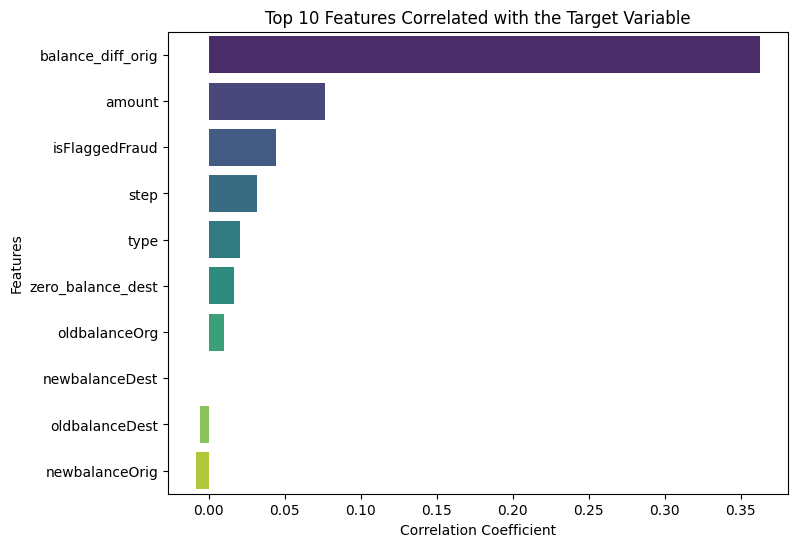

In [19]:
# Analyze correlation with the target variable ("isFraud")
if 'isFraud' in correlation_matrix.columns:
    target_corr = correlation_matrix['isFraud'].sort_values(ascending=False)
    print("Correlation with the target variable:")
    print(target_corr)

    # Visualize the strongest correlations with the target variable
    top_features = target_corr[1:11]  # Exclude correlation with itself
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
    plt.title('Top 10 Features Correlated with the Target Variable')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.show()
else:
    print("The 'isFraud' column does not exist in the dataset.")

In [20]:
# Check the range of correlation values
max_corr = correlation_matrix.where(~correlation_matrix.isna()).max().max()
min_corr = correlation_matrix.where(~correlation_matrix.isna()).min().min()

# Lower the threshold for moderate correlations
threshold = 0.8  # Adjust to a lower value
strong_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            strong_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print(f"Strongly correlated features (>|{threshold}|):")
for pair in strong_corr_pairs:
    print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

Strongly correlated features (>|0.8|):
newbalanceOrig and oldbalanceOrg : 1.00
newbalanceDest and oldbalanceDest : 0.98
balance_diff_dest and amount : -0.85


In [21]:
from sklearn.model_selection import train_test_split

# Assuming 'isFraud' is the target column in your dataset
X = data.drop(columns=['isFraud'])  # Features (remove target column)
y = data['isFraud']  # Target column

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# You can adjust test_size to 0.3 if you want 70% training and 30% testing

print(type(y))
print(y.dtype)
print(np.unique(y))
pd.Series(Y_train).value_counts()

<class 'pandas.core.series.Series'>
float64
[0. 1.]


isFraud
0.0    5083503
1.0       6593
Name: count, dtype: int64

# Outliers removal

In [22]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import IsolationForest

def check_outliers(X, Y, threshold=3, iqr_factor=1.5):
    """
    Check if outliers exist in the dataset (X and Y) using Z-score or IQR.
    Returns True if outliers are detected in either X or Y, False otherwise.
    """
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    
    # Ensure Y is a pandas Series
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)
    
    # Filter only numeric columns for X
    X_numeric = X_normal.select_dtypes(include=['number'])
    
    # Calculate Z-scores for X and Y
    z_scores_X = np.abs(stats.zscore(X_numeric))
    z_scores_Y = np.abs(stats.zscore(Y_normal))
    
    outliers_zscore_X = (z_scores_X > threshold).any().any()
    outliers_zscore_Y = (z_scores_Y > threshold).any()
    
    # Calculate IQR for X and Y
    Q1_X = X_numeric.quantile(0.25)
    Q3_X = X_numeric.quantile(0.75)
    IQR_X = Q3_X - Q1_X
    
    Q1_Y = Y.quantile(0.25)
    Q3_Y = Y.quantile(0.75)
    IQR_Y = Q3_Y - Q1_Y
    
    outliers_iqr_X = ((X_numeric < (Q1_X - iqr_factor * IQR_X)) | (X_numeric > (Q3_X + iqr_factor * IQR_X))).any().any()
    outliers_iqr_Y = ((Y_normal < (Q1_Y - iqr_factor * IQR_Y)) | (Y_normal > (Q3_Y + iqr_factor * IQR_Y))).any()
    
    return outliers_zscore_X or outliers_zscore_Y or outliers_iqr_X or outliers_iqr_Y
    
def remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=1.5, retain_percentage=0.95):
    """
    Removes outliers from normal transactions (class '0.0') while preserving class distribution.
    Ensures a minimum percentage of normal transactions are kept even if they are near the outlier boundary.
    """

    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    X_fraud = X[Y == 1]
    Y_fraud = Y[Y == 1]

    # Save original class distribution
    original_class_dist = Y.value_counts()

    # Outlier removal: Apply only to the normal class (majority class)
    if method == "auto":
        print("Automatically selecting outlier removal method...")
        if X_normal.std().mean() < threshold:
            print("Using Z-score for outlier removal...")
            X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)
        else:
            print("Using IQR for outlier removal...")
            X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
            Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "zscore":
        print("Using Z-score for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)

    elif method == "iqr":
        print("Using IQR for outlier removal...")
        X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
        Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "isolation_forest":
        print("Using Isolation Forest for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_if(X_normal, Y_normal)

    # Ensure we retain a minimum percentage of normal transactions
    retained_count = int(len(X_normal) * retain_percentage)
    if len(X_normal_cleaned) < retained_count:
        print(f"Warning: Keeping {retained_count} normal transactions, even if they are outliers.")
        X_normal_cleaned = X_normal.head(retained_count)
        Y_normal_cleaned = Y_normal.head(retained_count)

    # Reunify data while ensuring the class distribution is the same
    X_cleaned = pd.concat([X_normal_cleaned, X_fraud], axis=0).sort_index()
    Y_cleaned = pd.concat([Y_normal_cleaned, Y_fraud], axis=0).sort_index()

    # Check if class distribution remains the same
    new_class_dist = Y_cleaned.value_counts()
    if not original_class_dist.equals(new_class_dist):
        print(f"Warning: Class distribution has changed! Before: {original_class_dist}, After: {new_class_dist}")
    else:
        print("Class distribution is intact before and after outlier removal.")

    return X_cleaned, Y_cleaned

def remove_outliers_using_zscore(X, Y, threshold):
    """
    Removes outliers using the Z-score method.
    """
    z_scores = np.abs(stats.zscore(X))
    X_filtered = X[(z_scores < threshold).all(axis=1)]
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

def remove_outliers_using_iqr(X, iqr_factor=1.5):
    """
    Removes outliers using the IQR method.
    """
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    return X[~((X < (Q1 - iqr_factor * IQR)) | (X > (Q3 + iqr_factor * IQR))).any(axis=1)].copy()

def remove_outliers_using_if(X, Y, contamination=0.05):
    """
    Removes outliers using Isolation Forest.
    """
    model = IsolationForest(contamination=contamination, random_state=42)
    preds = model.fit_predict(X)
    X_filtered = X[preds != -1]  # IsolationForest marks outliers as -1
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

# Example usage:
# X_cleaned, Y_cleaned = remove_outliers(X, Y, method="auto", retain_percentage=0.95)


In [23]:
# Assuming X is your DataFrame (features) and Y is your Series (target)
outliers_exist = check_outliers(X, Y)
print(f"Outliers detected: {outliers_exist}")

# Step 2: Remove outliers if they exist
if outliers_exist:
    X_filtered, y_filtered = remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=2.0)
    print("Outliers removed.")
else:
    print("No outliers detected. Data is clean.")

print("Cleaned Features (X):")
print(X_filtered)
print(X_filtered.columns)
print("\nCleaned Target (Y):")
print(y_filtered)

Outliers detected: True
Automatically selecting outlier removal method...
Using Z-score for outlier removal...
0.0    6354407
1.0       8213
Name: count, dtype: int64, After: isFraud
0.0    6036686
1.0       8213
Name: count, dtype: int64
Outliers removed.
Cleaned Features (X):
         step  type    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0         0.0  0.75  0.000106       0.002855        0.003233        0.000000   
1         0.0  0.75  0.000020       0.000357        0.000391        0.000000   
2         0.0  1.00  0.000002       0.000003        0.000000        0.000000   
3         0.0  0.25  0.000002       0.000003        0.000000        0.000059   
4         0.0  0.75  0.000126       0.000697        0.000603        0.000000   
...       ...   ...       ...            ...             ...             ...   
6362615   1.0  0.25  0.003674       0.005701        0.000000        0.000000   
6362616   1.0  1.00  0.068272       0.105923        0.000000        0.000000   
6

In [24]:
from collections import Counter

# Check class distribution before and after outlier removal
print("Class distribution before outlier removal:", Counter(Y))
print("Class distribution after outlier removal:", Counter(y_filtered))

Class distribution before outlier removal: Counter({0.0: 6354407, 1.0: 8213})
Class distribution after outlier removal: Counter({0.0: 6036686, 1.0: 8213})


In [25]:
from sklearn.model_selection import train_test_split
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)

print("Unique classes in y_train after split:", np.unique(y_train))
print("Class distribution in y_train after split:\n", pd.Series(y_train).value_counts())

print("Distribution après split :", Counter(y_train))

Unique classes in y_train after split: [0. 1.]
Class distribution in y_train after split:
 isFraud
0.0    4829349
1.0       6570
Name: count, dtype: int64
Distribution après split : Counter({0.0: 4829349, 1.0: 6570})


In [26]:
print(X_train.columns)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud',
       'balance_diff_orig', 'balance_diff_dest', 'zero_balance_orig',
       'zero_balance_dest'],
      dtype='object')


In [27]:
X_train_filled = X_train.fillna(0)

# Check the result
X_train_filled.head(5)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,balance_diff_orig,balance_diff_dest,zero_balance_orig,zero_balance_dest
5981142,0.548518,0.75,0.000152,0.010871,0.012779,0.000000,0.000000,0.0,0.161923,0.890013,0.0,1.0
1605028,0.208895,0.00,0.001100,0.000256,0.002359,0.001481,0.001195,0.0,0.152203,0.890869,0.0,0.0
5851689,0.540431,0.00,0.001583,0.000357,0.003381,0.004368,0.004031,0.0,0.148455,0.891017,0.0,0.0
5247641,0.498652,0.25,0.002424,0.000335,0.000000,0.000635,0.001264,0.0,0.162413,0.888126,0.0,0.0
5470511,0.509434,0.75,0.000079,0.000004,0.000000,0.000000,0.000000,0.0,0.160761,0.890013,0.0,1.0


# ROS Oversampling

In [28]:
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

# Apply Random Oversampling
ros = RandomOverSampler(sampling_strategy=0.8, random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)
data_resampled = pd.concat([pd.DataFrame(X_resampled), pd.Series(y_resampled, name='Class')], axis=1)

# Display the class distribution after ROS
class_distribution_after = Counter(data_resampled['Class'])
print("Class Distribution After ROS:", class_distribution_after)

Class Distribution After ROS: Counter({0.0: 4829349, 1.0: 3863479})


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = y_resampled)

# Feature importance

In [30]:
# Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50),
    #"CataBoost": CatBoostClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50)
}

In [31]:
feature_importances = np.zeros(X_resampled.shape[1])

#X_resampled = X_resampled.astype({col: 'category' for col in X_resampled.columns if 'transaction_type' in col})

#X_resampled = pd.get_dummies(X_resampled, drop_first=True)
for name, model in models.items():
    # Train the model
    model.fit(X_resampled,y_resampled)
    if hasattr(model, "feature_importances_"):
        #feature_importances = model.feature_importances_
        feature_importances += model.feature_importances_
        print(f"{name} Feature Importances:\n{model.feature_importances_}")
    else:
        print(f"{name} does not have feature_importances_ attribute.")

Decision Tree Feature Importances:
[0.07548546 0.04284397 0.1095031  0.01781323 0.07526551 0.00377363
 0.00370194 0.00196545 0.65006828 0.01722976 0.00091378 0.00143589]
Random Forest Feature Importances:
[0.10074149 0.08923038 0.10620378 0.12019279 0.09897332 0.01262365
 0.02454862 0.00094564 0.34443755 0.07074688 0.02372886 0.00762705]
Extra Trees Feature Importances:
[0.1396347  0.27452001 0.07822908 0.052939   0.03923516 0.00646314
 0.01822965 0.00052323 0.19418754 0.01891955 0.12664991 0.05046902]
XGBoost Feature Importances:
[0.05331866 0.05139951 0.06835715 0.01994867 0.14797677 0.00806553
 0.0672619  0.00570113 0.516217   0.01626957 0.03642385 0.00906026]
AdaBoost Feature Importances:
[0.20480115 0.15336338 0.02955765 0.02161453 0.11228287 0.02127009
 0.         0.03223816 0.33509431 0.08977785 0.         0.        ]


In [32]:
avg_feature = feature_importances/len(models)

In [33]:
# Ensure 'isFraud' is removed only if it exists
if 'isFraud' in data_resampled.columns:
    original_features = data_resampled.drop(['isFraud'], axis=1).columns.values
else:
    original_features = data_resampled.columns.values

print("Features sorted by their score:")
sorted_features = sorted(zip(map(lambda x: round(x, 4), avg_feature), original_features), reverse=True)

# Unzip
sorted_scores, sorted_names = zip(*sorted_features)

# Compute cumulative importance
cumulative_importance = np.cumsum(sorted_scores)

# Index where cumulative importance reaches 90%
index = np.where(cumulative_importance >= 0.9)[0][0]
important_features = list(sorted_names[:index + 1])

# Check if features exist in X_resampled
existing_columns = set(X_resampled.columns)
filtered_features = []

for feature in important_features:
    matching_columns = [col for col in X_resampled.columns if feature in col]
    if matching_columns:
        filtered_features.extend(matching_columns)
    elif feature in existing_columns:
        filtered_features.append(feature)

# Select features
X_selected = X_resampled[filtered_features].values

print("Selected Features:", filtered_features)
print("Number of Selected Features:", len(filtered_features))

# Convert to DataFrame
X_selected_df = pd.DataFrame(X_selected, columns=filtered_features)
print(X_selected_df.head(10))


Features sorted by their score:
Selected Features: ['balance_diff_orig', 'type', 'step', 'newbalanceOrig', 'amount', 'oldbalanceOrg', 'balance_diff_dest']
Number of Selected Features: 7
   balance_diff_orig  type      step  newbalanceOrig    amount  oldbalanceOrg  \
0           0.161923  0.75  0.548518        0.012779  0.000152       0.010871   
1           0.152203  0.00  0.208895        0.002359  0.001100       0.000256   
2           0.148455  0.00  0.540431        0.003381  0.001583       0.000357   
3           0.162413  0.25  0.498652        0.000000  0.002424       0.000335   
4           0.160761  0.75  0.509434        0.000000  0.000079       0.000004   
5           0.156327  0.00  0.301887        0.005303  0.000569       0.003531   
6           0.160763  0.75  0.208895        0.000000  0.000070       0.000004   
7           0.161813  0.25  0.216981        0.000000  0.001738       0.000214   
8           0.160741  0.75  0.013477        0.000000  0.000121       0.000000   
9   

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_selected_df, y_resampled, train_size=0.8, test_size=0.2, random_state=42, stratify=y_resampled)

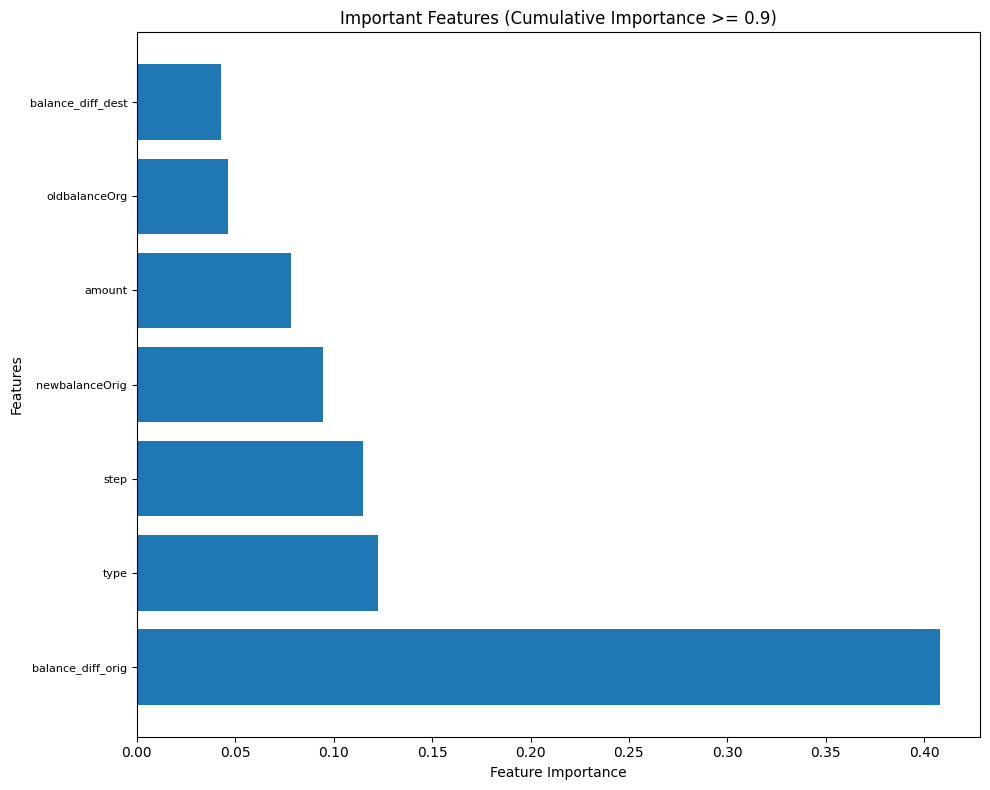

╒═══════════════════╤═══════════╕
│ Feature           │    Weight │
╞═══════════════════╪═══════════╡
│ balance_diff_orig │ 0.449686  │
├───────────────────┼───────────┤
│ type              │ 0.134796  │
├───────────────────┼───────────┤
│ step              │ 0.126529  │
├───────────────────┼───────────┤
│ newbalanceOrig    │ 0.104376  │
├───────────────────┼───────────┤
│ amount            │ 0.0864102 │
├───────────────────┼───────────┤
│ oldbalanceOrg     │ 0.051251  │
├───────────────────┼───────────┤
│ balance_diff_dest │ 0.0469525 │
╘═══════════════════╧═══════════╛


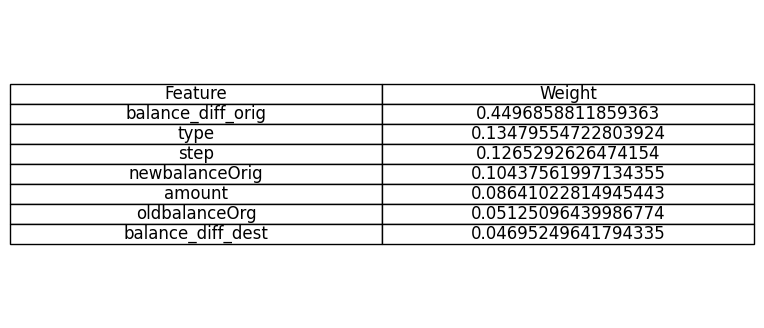

In [35]:
from tabulate import tabulate
# Step 10: Visualize the selected features
plt.figure(figsize=(10, 8))
plt.barh(range(len(important_features)), sorted_scores[:index+1], align='center')
plt.yticks(range(len(important_features)), important_features, fontsize=8)
plt.xlabel('Feature Importance', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.title('Important Features (Cumulative Importance >= 0.9)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 11: Display the selected features and their weights in a table
important_scores = sorted_scores[:index+1]
total_importance = np.sum(important_scores)
weights = important_scores / total_importance

table_data = [[feature, weight] for feature, weight in zip(important_features, weights)]
headers = ["Feature", "Weight"]

# Print the table
table_str = tabulate(table_data, headers, tablefmt="fancy_grid")
print(table_str)

# Save the table as a PDF
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
table = ax.table(cellText=table_data, colLabels=headers, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
#plt.savefig("feature_importance_table.pdf", bbox_inches="tight")

# GridSearch application

In [36]:
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
from tqdm import tqdm
import time
from joblib import parallel_backend

#start_time = time.time()
# Initialize progress bar
#tqdm_bar = tqdm(total=3, desc="Execution Progress")

# Ignore specific warning for XGBoost
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')

#encoder = OneHotEncoder(handle_unknown='ignore')
#print(set(X_train['colonne_catégorielle']) - set(X_test['colonne_catégorielle']))

# Define preprocessing pipeline
categorical_cols = X_train.select_dtypes(include=['object']).columns  # Detect categorical columns
# Create a ColumnTransformer to apply one-hot encoding to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # Apply one-hot encoding to categorical columns
    ], remainder='passthrough'  # Keep the rest of the columns as is
)
#tqdm_bar.update(1)
# Train and tune models with the preprocessing pipeline
def grid_search(model, param_grid, name):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])   
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], refit='accuracy', n_jobs=2)
    with parallel_backend('multiprocessing'):
        grid.fit(X_train, y_train)
    print(f"Best parameters for {name}: {grid.best_params_}")
    return grid.best_estimator_

In [37]:
# Corrected parameter grid (with proper step names for grid search)
param_grid_dt = {'classifier__min_samples_split': [2, 5, 10], 'classifier__max_depth': [10, 20, None]}  # Corrected to use classifier step
param_grid_rf = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10, 20, None]}
param_grid_et = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10, 20, None]}
param_grid_xgb = {'classifier__max_depth': [10, 20, None], 'classifier__learning_rate': [0.01, 0.1, 0.2], 'classifier__n_estimators': [100, 200]}
param_grid_ada = {'classifier__n_estimators': [50, 100, 200], 'classifier__learning_rate': [0.01, 0.1, 1]}  # Added classifier__ for AdaBoost

In [38]:
# Train and tune models
best_dt = grid_search(DecisionTreeClassifier(criterion='entropy', random_state=42), param_grid_dt, "Decision Tree")

Best parameters for Decision Tree: {'classifier__max_depth': None, 'classifier__min_samples_split': 2}


In [39]:
best_rf = grid_search(RandomForestClassifier(random_state=42), param_grid_rf, "Random Forest")

Best parameters for Random Forest: {'classifier__max_depth': None, 'classifier__n_estimators': 200}


In [40]:
best_et = grid_search(ExtraTreesClassifier(random_state=42), param_grid_et, "Extra Trees")

Best parameters for Extra Trees: {'classifier__max_depth': None, 'classifier__n_estimators': 200}


In [41]:
best_ada = grid_search(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50), param_grid_ada, "AdaBoost")

Best parameters for AdaBoost: {'classifier__learning_rate': 1, 'classifier__n_estimators': 200}


In [42]:
best_xgb = grid_search(XGBClassifier(n_estimators=50, eval_metric='logloss'), param_grid_xgb, "XGBoost")

Best parameters for XGBoost: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 20, 'classifier__n_estimators': 200}


In [43]:
print("Process completed successfully!")

Process completed successfully!


# Voting for best results

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# -----------------------------------------------------------
# 1. Setup Stratified K-Fold and Meta-Feature Arrays
# -----------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_models = 5  # Number of base models

meta_features_train = np.zeros((len(X_train), n_models))
meta_features_test = np.zeros((len(X_test), n_models))

print("✅ Step 1: Initialized meta-feature matrices")

# -----------------------------------------------------------
# 2. Define Base Models (already tuned)
# -----------------------------------------------------------
base_models = [
    ('dt', best_dt),
    ('rf', best_rf),
    ('et', best_et),
    ('xgb', best_xgb),
    ('ada', best_ada)
]

# -----------------------------------------------------------
# 3. Ensure Inputs Are in Correct Format
# -----------------------------------------------------------
if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train, columns=[f'feat_{i}' for i in range(X_train.shape[1])])
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=[f'feat_{i}' for i in range(X_test.shape[1])])

if isinstance(y_train, (pd.DataFrame, pd.Series)):
    y_train = y_train.values.ravel()

print("✅ Step 2: Data format verified")

# -----------------------------------------------------------
# 4. Generate Meta-Features via Stratified K-Fold
# -----------------------------------------------------------
imputer = SimpleImputer(strategy='mean')

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\n🔁 Step 3: Fold {fold}")

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    for i, (name, model) in enumerate(base_models):
        print(f"   ⚙️ Training {name.upper()} ...", end=" ")

        model.fit(X_tr, y_tr)

        try:
            meta_features_train[val_idx, i] = model.predict_proba(X_val)[:, 1]

        except ValueError as e:
            print(f"\n   ⚠️ ValueError detected: {e}")
            print("   ➡️ Attempting to fix column mismatch or NaN issues...")

            # 1️⃣ Determine expected features
            if hasattr(model, "feature_names_in_"):
                expected_cols = model.feature_names_in_
            elif hasattr(model, "named_steps") and "preprocessor" in model.named_steps:
                expected_cols = model.named_steps["preprocessor"].feature_names_in_
            else:
                expected_cols = X_tr.columns

            # 2️⃣ Align columns + fill missing values
            X_val_fixed = X_val.reindex(columns=expected_cols, fill_value=0)
            X_val_fixed = imputer.fit_transform(X_val_fixed)

            # 3️⃣ Retry prediction
            meta_features_train[val_idx, i] = model.predict_proba(X_val_fixed)[:, 1]

        print("done ✅")

print("\n✅ Step 4: Meta-features (train) generated successfully")

# -----------------------------------------------------------
# 5. Retrain on full training data and generate test meta-features
# -----------------------------------------------------------
for i, (name, model) in enumerate(base_models):
    print(f"🔁 Retraining {name.upper()} on full training data ...", end=" ")
    model.fit(X_train, y_train)

    try:
        meta_features_test[:, i] = model.predict_proba(X_test)[:, 1]
    except ValueError as e:
        print(f"\n⚠️ ValueError detected for {name}: {e}")
        print("➡️ Fixing columns for test set...")

        # Align and impute for test data
        if hasattr(model, "feature_names_in_"):
            expected_cols = model.feature_names_in_
        elif hasattr(model, "named_steps") and "preprocessor" in model.named_steps:
            expected_cols = model.named_steps["preprocessor"].feature_names_in_
        else:
            expected_cols = X_train.columns

        X_test_fixed = X_test.reindex(columns=expected_cols, fill_value=0)
        X_test_fixed = imputer.fit_transform(X_test_fixed)

        meta_features_test[:, i] = model.predict_proba(X_test_fixed)[:, 1]

    print("done ✅")

print("\n✅ Step 5: Meta-features (test) generated successfully")

✅ Step 1: Initialized meta-feature matrices
✅ Step 2: Data format verified

🔁 Step 3: Fold 1
done ✅Training DT ... 
   ⚙️ Training RF ... 

In [ ]:
from sklearn.ensemble import VotingClassifier

print("Step 4: Meta-features (train) generated")

# -----------------------------------------------------------
# 5. Fit each base model on the full training data and get test predictions
# -----------------------------------------------------------

# Ensure X_train and X_test are DataFrames for column alignment
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test)

# Initialize meta_features_test array
meta_features_test = np.zeros((X_test.shape[0], len(base_models)))

for i, (name, model) in enumerate(base_models):
    # Fit the base model
    model.fit(X_train, y_train)

    # Handle potential missing columns in X_test
    missing_cols = set(X_train.columns) - set(X_test.columns)
    for col in missing_cols:
        X_test[col] = 0  # fill missing columns with 0
    # Ensure column order matches training data
    X_test_aligned = X_test[X_train.columns]

    # Get meta-features for the test set
    meta_features_test[:, i] = model.predict_proba(X_test_aligned)[:, 1]

print("Step 5: Meta-features (test) generated successfully")

# -----------------------------------------------------------
# 6. Prepare for Voting Classifier
# -----------------------------------------------------------
y_train = np.squeeze(y_train)

# Ensure meta_features_train is a DataFrame
if not isinstance(meta_features_train, pd.DataFrame):
    meta_features_train = pd.DataFrame(
        meta_features_train,
        columns=[name for name, _ in base_models]
    )

print("Step 6: Preparing for Voting Classifier")

# -----------------------------------------------------------
# 7. Define and Tune Voting Classifier with GridSearchCV
# -----------------------------------------------------------
voting_clf = VotingClassifier(estimators=base_models, voting='soft')

param_grid_voting = {
    'weights': [
        (1, 1, 1, 1, 1),
        (1, 2, 2, 3, 1),
        (2, 1, 1, 1, 2),
        (3, 2, 1, 2, 1),
        (1, 1, 2, 2, 3)
    ]
}

print("Step 7: Starting GridSearchCV for Voting Classifier")

# Convert y_train to 1D array if needed
if isinstance(y_train, (pd.DataFrame, pd.Series)):
    y_train = y_train.values.ravel()

grid_voting = GridSearchCV(
    estimator=voting_clf,
    param_grid=param_grid_voting,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_voting.fit(meta_features_train, y_train)

best_voting = grid_voting.best_estimator_
print(f"✅ Best Voting Weights: {grid_voting.best_params_}")
print("Step 8: Voting Classifier tuning completed successfully.")


# Second Stage : LSTM predictions

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import Recall
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # monitor validation loss
    factor=0.5,            # reduce LR by half
    patience=3,            # wait 3 epochs without improvement
    min_lr=1e-6            # do not go below this LR
)

best_voting.fit(X_train, y_train)

# Get Predictions from Voting Classifier (probabilities)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities of class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities of class 1

# Reshape for LSTM (required shape: [samples, time_steps, features])
X_train_lstm = y_pred_voting_train.reshape(-1, 1, 1)  # Shape (samples, 1, 1)
X_test_lstm = y_pred_voting_test.reshape(-1, 1, 1)  # Shape (samples, 1, 1)

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Check the shape of the labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)



lstm_model_raw = Sequential([
    #Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    
   # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.3),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model_raw.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])
# Train the LSTM Meta-Learner

start_train_raw = time.time()

# Train the LSTM Meta-Learner
history_raw = lstm_model_raw.fit(X_train_lstm, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm, y_test_cat), callbacks=[reduce_lr])

end_train_raw = time.time()
training_time_raw = end_train_raw - start_train_raw

# Final performance results

In [ ]:
start_infer_raw = time.time()
y_pred_lstm = lstm_model_raw.predict(X_test_lstm)
end_infer_raw = time.time()
inference_time_raw = end_infer_raw - start_infer_raw

y_pred_lstm_labels = np.argmax(y_pred_lstm, axis=1)  # Correct

n_samples_raw = len(X_test_lstm)
latency_ms_raw = (inference_time_raw / n_samples_raw) * 1000
throughput_raw = n_samples_raw / inference_time_raw


In [ ]:
print("Performance without Autoencoder :")

print(f"Training Time (s): {training_time_raw:.4f}")
print(f"Inference Time (s): {inference_time_raw:.4f}")
print(f"Latency (ms/sample): {latency_ms_raw:.4f}")
print(f"Throughput (samples/s): {throughput_raw:.2f}")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_labels))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lstm_labels))

print("Accuracy:", accuracy_score(y_test, y_pred_lstm_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
# Compute percentages
fp_percent = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0
fn_percent = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0

# Create a DataFrame
df = pd.DataFrame({
    "Metric": ["False Positives (FP)", "False Negatives (FN)"],
    "Count": [fp, fn],
    "Percentage (%)": [f"{fp_percent:.2f}%", f"{fn_percent:.2f}%"]
})

# Print the table
print(df)

# Add autoencoders

In [ ]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score

# Define the Autoencoder
input_shape = (X_train_lstm.shape[1],)  # Adjust input shape based on your data
input_layer = Input(shape=input_shape)

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(128, activation='relu')(encoded)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(input_shape[0], activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Define EarlyStopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

start_train = time.time()

# Train the Autoencoder
autoencoder.fit(X_train_lstm, X_train_lstm,
                epochs=50,
                batch_size=32,
                validation_data=(X_test_lstm, X_test_lstm),
               callbacks=[early_stopping])

# Print model summary
autoencoder.summary()

# Step 3: Create an Encoder Model for Feature Extraction
encoder = Model(input_layer, encoded)

# Step 4: LSTM Meta-Learner on top of the encoded features
# (Assuming best_voting is a previously trained ensemble model)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities for class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Get the encoded representations (compressed features) for both train and test data
X_train_encoded = encoder.predict(X_train_lstm)
X_test_encoded = encoder.predict(X_test_lstm)

# Check the shape of the categorical labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)

In [ ]:
X_train_encoded = X_train_encoded[:y_train_cat.shape[0]]
X_test_encoded = X_test_encoded[:y_test_cat.shape[0]]

# Ensure the shape is (samples, time_steps, features) for LSTM
X_train_lstm_ae = X_train_encoded.reshape(X_train_encoded.shape[0], 1, -1)
X_test_lstm_ae = X_test_encoded.reshape(X_test_encoded.shape[0], 1, -1)


In [ ]:

lstm_model = Sequential([
    #Input(shape=(X_train_lstm_ae.shape[1], X_train_lstm_ae.shape[2])),
    # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.3),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])
lstm_model.summary()
history = lstm_model.fit(X_train_lstm_ae, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm_ae, y_test_cat), callbacks=[reduce_lr])

end_train = time.time()
training_time = end_train - start_train

In [ ]:
start_infer = time.time()
y_pred_lstm_ae = lstm_model.predict(X_test_lstm_ae)

end_infer = time.time()
inference_time = end_infer - start_infer


print(y_pred_lstm_ae.shape)  # (1734184, 2)

y_pred_lstm_ae_labels = np.argmax(y_pred_lstm_ae, axis=1)

n_samples = len(X_test_lstm_ae)
latency_ms = (inference_time / n_samples) * 1000
throughput = n_samples / inference_time

In [ ]:
print("Performance with Autoencoder :")

print(f"Training Time (s): {training_time:.4f}")
print(f"Inference Time (s): {inference_time:.4f}")
print(f"Latency (ms/sample): {latency_ms:.4f}")
print(f"Throughput (samples/s): {throughput:.4f}")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_ae_labels))

cm1 = confusion_matrix(y_test, y_pred_lstm_ae_labels)

print("Confusion matrix With autoencoder:")
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
#print("Confusion matrix:")
#print(confusion_matrix(y_test, y_pred_lstm_ae_labels))
print("Accuracy:", accuracy_score(y_test, y_pred_lstm_ae_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_ae_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_ae_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_ae_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_ae_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_ae_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_ae_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_ae_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_ae_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_ae_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
# Compute percentages
fp_percent = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0
fn_percent = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0

# Create a DataFrame
df = pd.DataFrame({
    "Metric": ["False Positives (FP)", "False Negatives (FN)"],
    "Count": [fp, fn],
    "Percentage (%)": [f"{fp_percent:.2f}%", f"{fn_percent:.2f}%"]
})

# Print the table
print(df)

In [ ]:
# Extract loss values
train_loss = history.history['loss']  # Training loss for each epoch
val_loss = history.history['val_loss']  # Validation loss for each epoch (if validation data is provided)

train_loss2 = history_raw.history['loss']
val_loss2 = history_raw.history['val_loss']

# Plotting the loss curves for both models
plt.figure(figsize=(10, 6))

# Plot for Model 1
plt.plot(train_loss, label='With Autoencoder - Training Loss', color='blue')
plt.plot(val_loss, label='With Autoencoder - Validation Loss', color='orange')

# Plot for Model 2
plt.plot(train_loss2, label='Without Autoencoder - Training Loss', color='green')
plt.plot(val_loss2, label='Without Autoencoder - Validation Loss', color='red')

# Adding labels and title
plt.title('LSTM Model Loss vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

In [ ]:
train_acc1 = history.history['accuracy']
val_acc1 = history.history['val_accuracy']

train_acc2 = history_raw.history['accuracy']
val_acc2 = history_raw.history['val_accuracy']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_acc1, label='With Autoencoder - Training Accuracy', color='blue')
plt.plot(val_acc1, label='With Autoencoder - Validation Accuracy', color='orange')

plt.plot(train_acc2, label='Without Autoencoder - Training Accuracy', color='green')
plt.plot(val_acc2, label='Without Autoencoder - Validation Accuracy', color='red')


plt.title('LSTM Model Accuracy vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
train_recall1 = history_raw.history['recall']
val_recall1 = history_raw.history['val_recall']

train_recall2 = history.history['recall_1']
val_recall2 = history.history['val_recall_1']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_recall1, label='Without Autoencoder - Training Racall', color='green')
plt.plot(val_recall1, label='Without Autoencoder - Validation Recall', color='red')

plt.plot(train_recall2, label='With Autoencoder - Training Recall', color='blue')
plt.plot(val_recall2, label='With Autoencode - Validation Recall', color='orange')


plt.title('LSTM Model Racall vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()

In [ ]:
# Compute percentages
fp_percent = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0
fn_percent = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0

# Create a DataFrame
df = pd.DataFrame({
    "Metric": ["False Positives (FP)", "False Negatives (FN)"],
    "Count": [fp, fn],
    "Percentage (%)": [f"{fp_percent:.2f}%", f"{fn_percent:.2f}%"]
})

# Print the table
print(df)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Accuracy and Recall over epochs
train_acc = history.history['accuracy']          # training accuracy per epoch
val_acc   = history.history['val_accuracy']      # validation accuracy per epoch

train_acc_raw = history_raw.history['accuracy']          # training accuracy per epoch
val_acc_raw   = history_raw.history['val_accuracy']      # validation accuracy per epoch


train_recall = history.history['recall']
val_recall = history.history['val_recall']

train_recall_raw = history_raw.history['recall_1']
val_recall_raw = history_raw.history['val_recall_1']


# Convert to numpy arrays
train_acc = np.array(train_acc)
val_acc   = np.array(val_acc)
train_acc_raw = np.array(train_acc_raw)
val_acc_raw   = np.array(val_acc_raw)

train_recall = np.array(train_recall)
val_recall   = np.array(val_recall)
train_recall_raw = np.array(train_recall_raw)
val_recall_raw   = np.array(val_recall_raw)

train_loss = np.array(history.history['loss'])
val_loss   = np.array(history.history['val_loss'])
train_loss2 = np.array(history_raw.history['loss'])
val_loss2   = np.array(history_raw.history['val_loss'])

# Compute generalization gaps
acc_gap = train_acc - val_acc
acc_gap_raw = train_acc_raw - val_acc_raw

recall_gap = train_recall - val_recall
recall_gap_raw = train_recall_raw - val_recall_raw

loss_gap = val_loss - train_loss
loss_gap_raw = val_loss2 - train_loss2

# Identify overfitting epochs
overfit_loss_epochs = np.where(loss_gap > 0)[0]
overfit_loss_epochs_raw = np.where(loss_gap_raw > 0)[0]

overfit_acc_epochs = np.where(acc_gap > 0)[0]
overfit_acc_epochs_raw = np.where(acc_gap_raw > 0)[0]

overfit_recall_epochs = np.where(recall_gap > 0)[0]
overfit_recall_epochs_raw = np.where(recall_gap_raw > 0)[0]

# Plotting
plt.figure(figsize=(18,5))

# Accuracy gap
plt.subplot(1,3,1)
plt.plot(acc_gap, label='SV2LSTM Accuracy Gap', color='blue', linestyle='-')
plt.plot(acc_gap_raw, label='SV2LSTM+AE Accuracy Gap', color='orange', linestyle='--')
plt.scatter(overfit_acc_epochs, acc_gap[overfit_acc_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_acc_epochs_raw, acc_gap_raw[overfit_acc_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Accuracy')
plt.grid(False)
plt.legend()

# Recall gap
plt.subplot(1,3,2)
plt.plot(recall_gap, label='SV2LSTM Recall Gap', color='blue', linestyle='-')
plt.plot(recall_gap_raw, label='SV2LSTM+AE Recall Gap', color='orange', linestyle='--')
plt.scatter(overfit_recall_epochs, recall_gap[overfit_recall_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_recall_epochs_raw, recall_gap_raw[overfit_recall_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Recall')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Recall')
plt.grid(False)
plt.legend()

# Loss gap
plt.subplot(1,3,3)
plt.plot(loss_gap, label='SV2LSTM Loss Gap', color='blue')
plt.plot(loss_gap_raw, label='SV2LSTM+AE Loss Gap', color='orange', linestyle='--')
plt.scatter(overfit_loss_epochs, loss_gap[overfit_loss_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_loss_epochs_raw, loss_gap_raw[overfit_loss_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Loss')
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.grid(False)
plt.legend()

plt.tight_layout()
# Save the figure
plt.savefig("SV2LSTM_PaySim_ROS_generalization_gap.png", dpi=300)  # high-resolution PNG
plt.show()

# Optional: print first overfitting epoch for each metric
if len(overfit_loss_epochs) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM): {overfit_loss_epochs[0]+1}")
if len(overfit_loss_epochs_raw) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM+AE): {overfit_loss_epochs_raw[0]+1}")
if len(overfit_acc_epochs) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM): {overfit_acc_epochs[0]+1}")
if len(overfit_acc_epochs_raw) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM+AE): {overfit_acc_epochs_raw[0]+1}")
if len(overfit_recall_epochs) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM): {overfit_recall_epochs[0]+1}")
if len(overfit_recall_epochs_raw) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM+AE): {overfit_recall_epochs_raw[0]+1}")


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import os
sns.set(style="whitegrid")

# ---------- Helper utilities ----------
def compute_basic_metrics(y_true, y_pred_labels, y_pred_proba=None):
    acc = accuracy_score(y_true, y_pred_labels)
    prec = precision_score(y_true, y_pred_labels, zero_division=0)
    rec = recall_score(y_true, y_pred_labels, zero_division=0)
    f1 = f1_score(y_true, y_pred_labels, zero_division=0)
    f2 = fbeta_score(y_true, y_pred_labels, beta=2, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred_labels)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_labels).ravel()
    specificity = tn / (tn + fp + 1e-12)
    gmean = np.sqrt(rec * specificity)

    auc = np.nan
    if y_pred_proba is not None and len(np.unique(y_true)) > 1:
        try:
            # Handle 2D softmax output
            if y_pred_proba.ndim == 2 and y_pred_proba.shape[1] > 1:
                y_pred_proba = y_pred_proba[:, 1]
            auc = roc_auc_score(y_true, y_pred_proba)
        except Exception:
            auc = np.nan

    return {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "f2": f2,
        "mcc": mcc, "specificity": specificity, "gmean": gmean, "auc": auc
    }

# ---------- Drift scenario functions ----------
def gradual_mean_shift(X, intensity=0.0):
    Xs = X.copy()
    if Xs.ndim == 3:
        _, _, n_features = Xs.shape
        shifts = (np.linspace(0, 1, n_features) * intensity).reshape(1, 1, n_features)
        return Xs + shifts
    else:
        _, n_features = Xs.shape
        shifts = (np.linspace(0, 1, n_features) * intensity).reshape(1, n_features)
        return Xs + shifts

def sudden_shift(X, intensity=1.0, features_frac=0.2):
    Xs = X.copy()
    n_features = Xs.shape[-1] if Xs.ndim == 3 else Xs.shape[1]
    n_change = max(1, int(n_features * features_frac))
    idx = np.random.choice(n_features, n_change, replace=False)
    Xs[..., idx] += intensity
    return Xs

def add_noise(X, noise_level=0.1):
    return X + np.random.normal(scale=noise_level, size=X.shape)

#def label_shift(y, new_pos_rate):
 #   y = y.copy()
 #   n = len(y)
 #   current_pos = np.sum(y == 1)
 #   target_pos = int(new_pos_rate * n)
 #   if target_pos > current_pos:
 #       neg_idx = np.where(y == 0)[0]
 #       flip_idx = np.random.choice(neg_idx, max(0, target_pos - current_pos), replace=False)
 #       y[flip_idx] = 1
 #   elif target_pos < current_pos:
 #       pos_idx = np.where(y == 1)[0]
 #       flip_idx = np.random.choice(pos_idx, max(0, current_pos - target_pos), replace=False)
 #       y[flip_idx] = 0
 #   return y

def label_shift(y, new_pos_rate):
    y = y.copy()
    y_np = y.to_numpy()  # Convert to NumPy for positional indexing

    pos_idx = np.where(y_np == 1)[0]
    current_pos = len(pos_idx)
    target_pos = int(len(y_np) * new_pos_rate)

    if current_pos > target_pos:
        flip_idx = np.random.choice(pos_idx, max(0, current_pos - target_pos), replace=False)
        y_np[flip_idx] = 0

    return pd.Series(y_np, index=y.index)

def new_fraud_pattern(X, y, feature_idx=0, shift=2.0):
    Xs = X.copy()
    fraud_idx = np.where(y == 1)[0]
    if len(fraud_idx) > 0:
        Xs[fraud_idx, ..., feature_idx] += shift
    return Xs, y

# ---------- Scenario definitions ----------
drift_scenarios = {
    "no_drift": lambda X, y, t, intensity: (X, y),
    "gradual_mean_shift": lambda X, y, t, intensity: (gradual_mean_shift(X, intensity * (t+1)), y),
    "sudden_shift": lambda X, y, t, intensity: (sudden_shift(X, intensity if t >= 2 else 0.0), y),
    "add_noise": lambda X, y, t, intensity: (add_noise(X, noise_level=intensity*(t+1)), y),
#    "label_shift": lambda X, y, t, intensity: (X, label_shift(y, new_pos_rate=min(0.5, 0.01 + intensity*(t+1)*0.05))),
    "new_fraud_pattern": lambda X, y, t, intensity: new_fraud_pattern(X, y, feature_idx=0, shift=intensity*(t+1))
}

# ---------- Classical Models ----------
rf = RandomForestClassifier(random_state=42)
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
xgb = XGBClassifier(n_estimators=50, use_label_encoder=False, eval_metric='logloss')
et = ExtraTreesClassifier(random_state=42)
ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50)

classical_models = {"rf": rf, "dt": dt, "xgb": xgb, "et": et, "ada": ada}

# ---------- Train baseline models ----------
X_train_flat = X_train.reshape(X_train.shape[0], -1) if X_train.ndim == 3 else X_train
for name, model in classical_models.items():
    print(f"Training {name}...")
    model.fit(X_train_flat, y_train)

# ---------- Parameters ----------
n_windows = 5
window_size = int(len(y_test) / n_windows)
intensity = 1.0

X_test_flat = X_test.reshape(X_test.shape[0], -1) if X_test.ndim == 3 else X_test
X_test_lstm_base = X_test_lstm
X_test_ae_base = X_test_lstm_ae

# ---------- Results ----------
records = []

for scenario_name, scenario_fn in drift_scenarios.items():
    print(f"\n=== Scenario: {scenario_name} ===")
    for w in range(n_windows):
        start_idx = w * window_size
        end_idx = start_idx + window_size if w < n_windows - 1 else len(y_test)
        X_win_flat = X_test_flat[start_idx:end_idx]
        X_win_lstm = X_test_lstm_base[start_idx:end_idx]
        X_win_ae = X_test_ae_base[start_idx:end_idx]
        y_win = y_test[start_idx:end_idx]

        # Apply drift scenario
        X_flat_d, y_d = scenario_fn(X_win_flat, y_win, w, intensity)
        X_lstm_d, y_d2 = scenario_fn(X_win_lstm, y_win, w, intensity)
        X_ae_d, y_d3 = scenario_fn(X_win_ae, y_win, w, intensity)

        # ----- LSTM -----
        start_inf = time.time()
        y_proba_lstm = lstm_model_raw.predict(X_lstm_d, verbose=0)
        end_inf = time.time()
        inference_time_lstm = end_inf - start_inf
        y_label_lstm = np.argmax(y_proba_lstm, axis=1)
        metrics_lstm = compute_basic_metrics(y_d2, y_label_lstm, y_proba_lstm.ravel())
        latency_lstm = (inference_time_lstm / len(y_d2)) * 1000
        throughput_lstm = len(y_d2) / inference_time_lstm

        # ----- AE-LSTM -----
        start_inf = time.time()
        y_proba_ae = lstm_model.predict(X_ae_d, verbose=0)
        end_inf = time.time()
        inference_time_ae = end_inf - start_inf
        y_label_ae = np.argmax(y_proba_ae, axis=1)
        metrics_ae = compute_basic_metrics(y_d3, y_label_ae, y_proba_ae.ravel())
        latency_ae = (inference_time_ae / len(y_d3)) * 1000
        throughput_ae = len(y_d3) / inference_time_ae
        
        # Store LSTM and AE-LSTM metrics in the record dictionary
        # Dictionary unpacking with prefixes to distinguish between models
        rec = {
            "scenario": scenario_name,
            "window": w,
            "samples": len(y_d),
            "lstm_inference_time": inference_time_lstm,
            "lstm_latency_ms": latency_lstm,
            "lstm_throughput": throughput_lstm,
            "ae_inference_time": inference_time_ae,
            "ae_latency_ms": latency_ae,
            "ae_throughput": throughput_ae,
            **{f"lstm_{k}": v for k, v in metrics_lstm.items()},
            **{f"ae_{k}": v for k, v in metrics_ae.items()}
        }

        # ----- Classical models -----
        # Evaluate each classical ML model
        for name, model in classical_models.items():
            start_inf = time.time()
            y_proba = model.predict_proba(X_flat_d)[:, 1]
            end_inf = time.time()
            inf_time = end_inf - start_inf
            y_label = (y_proba > 0.5).astype(int)
            metrics = compute_basic_metrics(y_d, y_label, y_proba)
            latency = (inf_time / len(y_d)) * 1000
            throughput = len(y_d) / inf_time
            # Add model metrics to record dictionary with appropriate prefixes
            rec.update({
                f"{name}_inference_time": inf_time,
                f"{name}_latency_ms": latency,
                f"{name}_throughput": throughput,
                **{f"{name}_{k}": v for k, v in metrics.items()}
            })
        # Add completed record to collection and print progress update
        records.append(rec)
        print(f"Scenario={scenario_name} | Window={w} | AE-AUC={metrics_ae['auc']:.3f}")

# ---------- Save results ----------
df = pd.DataFrame(records)
df.to_csv("drift_scenario_comparison.csv", index=False)
print("\n✅ Results saved to drift_scenario_comparison.csv")

# ---------- Visualization ----------
def plot_metric_over_windows(df, scenario, metric, models):
    sub = df[df["scenario"] == scenario]
    plt.figure(figsize=(9, 4))
    for m in models:
        plt.plot(sub["window"], sub[f"{m}_{metric}"], marker="o", label=m.upper())
    plt.xlabel("Window")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} over time – {scenario}")
    plt.legend()
    plt.show()

# ---------- Save results separately ----------
# Create a results folder if it doesn't exist
results_dir = "drift_results"
os.makedirs(results_dir, exist_ok=True)

df = pd.DataFrame(records)
model_names = ["lstm", "ae", "rf", "dt", "xgb", "et", "ada"]

for model in model_names:
    # Select columns related to this model plus general context columns
    cols = ["scenario", "window", "samples"] + [c for c in df.columns if c.startswith(model + "_")]
    df_model = df[cols]
    file_name = os.path.join(results_dir, f"{model}_drift_results.csv")
    df_model.to_csv(file_name, index=False)
    print(f"✅ Saved {file_name} ({len(df_model)} rows)")